In [1]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy
from functools import reduce

from torch import nn
import pickle as pkl
from umap import UMAP

from model import DNN
from run_sim import Config, run_sim, create_data, train_model
from utils import *
from tqdm import tqdm
from utils import alignment_score, calc_PR, calc_NC1
import matplotlib as mpl
from functools import reduce



In [2]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [3]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np


def multiclass_functional_margin(W, x, y):
    W = W / np.linalg.norm(W)
    scores = x@W  # shape (K,)
    true_score = scores[y]
    max_other_score = np.max(np.delete(scores, y))
    return true_score - max_other_score


def train_svm(X, y, W_init=None):
    X_train = torch.tensor(X, dtype=torch.float32)
    y_train = torch.tensor(y, dtype=torch.long)

    num_classes = len(np.unique(y))
    num_features = X.shape[1]

    # 2. One-vs-Rest Linear SVM model
    class OvRLinearSVM(nn.Module):
        def __init__(self, in_features, num_classes):
            super().__init__()
            self.weights = nn.Parameter(torch.zeros(num_classes, in_features))

            if W_init is not None:
                self.weights.data = torch.tensor(W_init, dtype=torch.float32)

        def forward(self, x):
            return x @ self.weights.t() # + self.biases  # shape: (batch, num_classes)

    model = OvRLinearSVM(num_features, num_classes)

    # 3. Define Hard-Margin Hinge Loss (no slack)
    def hard_margin_loss(outputs, labels):
        """
        Multi-class One-vs-Rest hard-margin hinge loss.
        """
        n = outputs.shape[0]
        true_class_scores = outputs[torch.arange(n), labels].unsqueeze(1)  # (n, 1)
        margins = outputs - true_class_scores + 2  # delta=1
        margins[torch.arange(n), labels] = 0  # Don't penalize correct class
        loss = torch.sum(torch.clamp(margins, min=0)) 
        return loss

    # 4. Training Loop
    loss_l = []
    accuracy_l = []
    optimizer = optim.SGD(model.parameters(), lr=1e-2)
    num_epochs = 10000
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = hard_margin_loss(outputs, y_train)
        loss.backward()
        optimizer.step()

        # Enforce hard-margin constraint: no slack
        with torch.no_grad():
            outputs = model(X_train)
            true_class_scores = outputs[torch.arange(len(y_train)), y_train]
            other_class_scores = torch.cat([
                outputs[i, torch.arange(num_classes) != y_train[i]]
                for i in range(len(y_train))
            ]).view(len(y_train), -1)
                # break
        loss_l.append(loss.item())
        pred = torch.argmax(outputs, dim=1)
        acc = (pred == y_train).float().mean()
        accuracy_l.append(acc.item())
        # if epoch % (num_epochs//10) == 0:
        #     print(f"Epoch {epoch}, Loss: {loss.item():.2f}, Train Acc: {acc:.2f}")

    # Final evaluation
    with torch.no_grad():
        preds = torch.argmax(model(X_train), dim=1)
        accuracy = (preds == y_train).float().mean()

        if torch.all(true_class_scores.unsqueeze(1) > other_class_scores + 1):
            print(f"Hard margin separation achieved")
        print(f"\nFinal training accuracy: {accuracy:.2f}")
    
    W = model.weights.detach().numpy()
    margins = np.mean([multiclass_functional_margin(W.T, x_curr, y_curr) for x_curr, y_curr in zip(X, y)])
    plt.plot(loss_l)
    plt.gca().twinx().plot(accuracy_l, c='r')
    plt.show()
    return margins, W

c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


-43.11427148362563
1.0


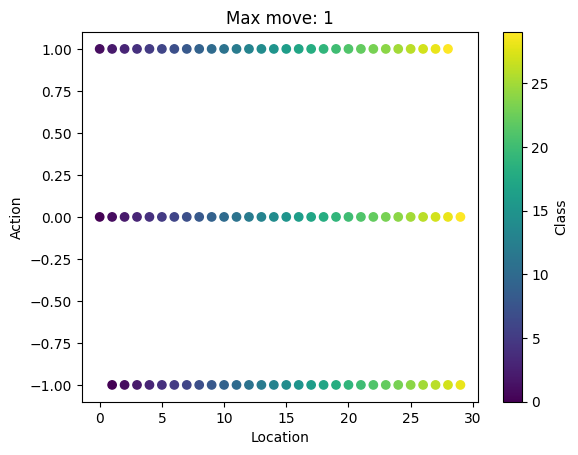

c:\Users\avivra\Desktop\cursor_projects\RepresentationShaping\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


-39.56464799928664
1.0


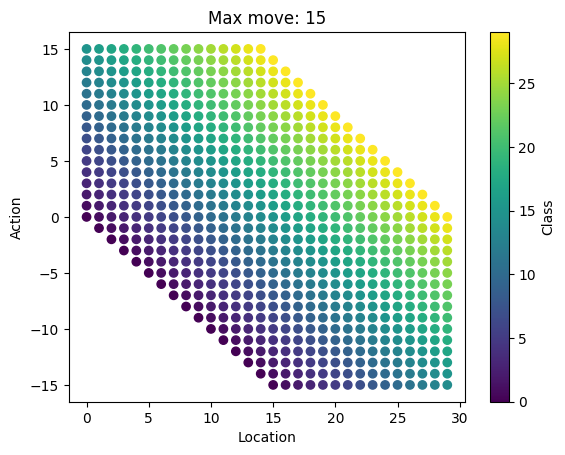

In [ ]:
C = Config()

C.length_corridors = [30]
max_move_l = [0, 1, C.length_corridors[0]//2][1:]
W_l = []
for max_move in max_move_l:
    C.max_move = max_move

    X, y, corridor, loc_X, loc_y, action_taken, dim_l, input_size, output_size, n_actions = create_data(C)
    
    # L = C.length_corridors[0]
    # A = C.max_move
    # n_model = 1
    # Win = np.concatenate([np.arange(1,L+1, 1), np.arange(-A,A+1)])[:,None]
    # Wout = 1/n_model*np.arange(1,L+1, 1)[None,:]**n_model
    # b = -1/(n_model+1)*np.arange(1,L+1, 1)[None, :]**(n_model+1)

    # W1,W2 = get_AB(X, Win, Wout, b, 2)
    # W = W1 @ W2

    # X_np = X
    # y_np = y
    # y = y.argmax(1)
    # margins, W = train_svm(X, y, W_init=None)
    # INSERT_YOUR_CODE
    from sklearn.linear_model import LogisticRegression

    # Train a multinomial logistic regression (softmax regression)
    svm = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=10000.0, max_iter=10000)
    svm.fit(X, y.argmax(1))

    # Extract weights for each class (shape: n_classes x n_features)
    W = svm.coef_

    # For margin calculation, you could use:
    # margins = svm.decision_function(X_scaled)
    # But to keep the interface similar:
    margins = np.mean(np.min(svm.decision_function(X) * (2 * (np.eye(W.shape[0])[y.argmax(1)] - 0.5)), axis=1))
    print(margins)
    accuracy = np.mean(svm.predict(X) == y.argmax(1))
    print(accuracy)


    W_l.append(W)
    # Standardize features (important for SVMs)
    # scaler = StandardScaler()
    # INSERT_YOUR_CODE
    plt.scatter(loc_X, action_taken, c=loc_y)
    plt.xlabel('Location')
    plt.ylabel('Action')
    plt.title(f'Max move: {max_move}')
    plt.colorbar(label='Class')
    plt.show()

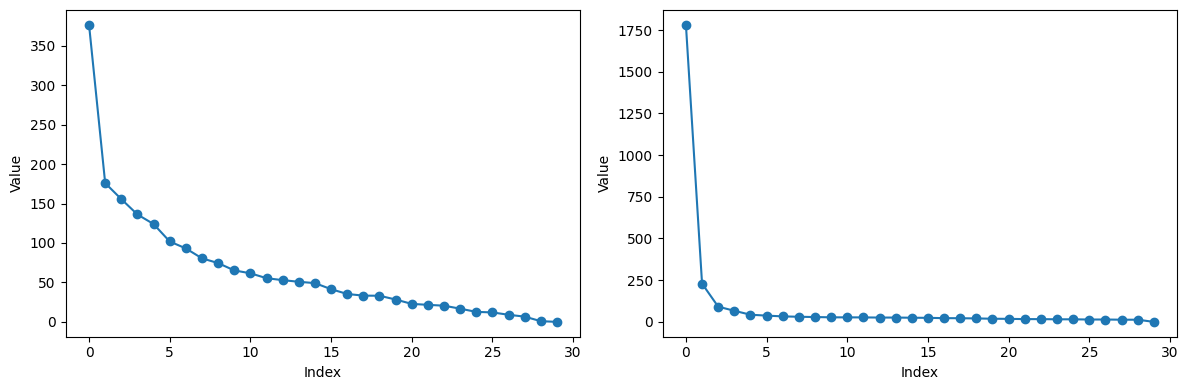

In [84]:
# Compute SVD of W

# Plot the first few left and right singular vectors
fig, axs = plt.subplots(1, len(W_l), figsize=(12, 4))
for i, W in enumerate(W_l):
    U, S, Vt = np.linalg.svd(W, full_matrices=False)
    # Plot the first left singular vector (U[:,0])
    axs[i].plot(S, marker='o')
    axs[i].set_xlabel('Index')
    axs[i].set_ylabel('Value')
plt.tight_layout()
plt.show()

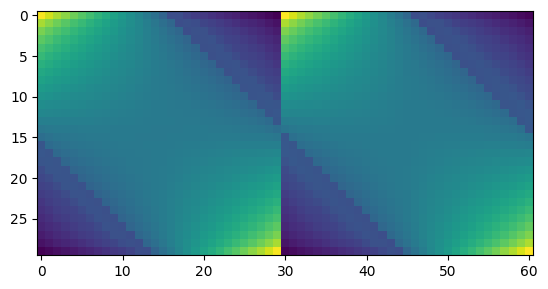

In [85]:
plt.imshow(W_l[-1])

In [45]:
W = W_l[0]
print((W@X.T)[:,:2])
print(y[:2])

[[ 3.359997   -0.67000818]
 [ 1.34999955  1.33999932]
 [-4.71000507 -0.67000818]]
[0 1]


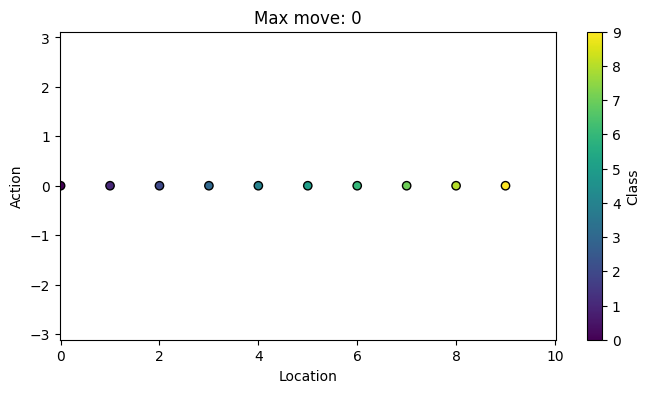

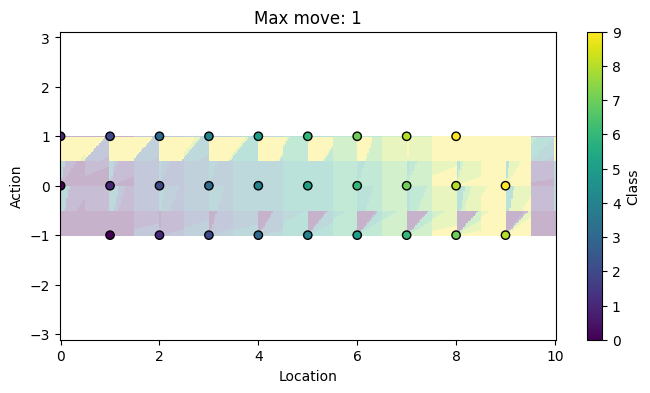

In [92]:

i=0
for i in range(len(max_move_l)):
    C.max_move = max_move_l[i]
    W = W_l[i]
    def classify_point(x, W):
        return np.argmax(x@W.T)
    X, y, corridor, loc_X, loc_y, action_taken, dim_l, input_size, output_size, n_actions = create_data(C)
    # Create a meshgrid over the plot area
    x_min, x_max = 0, C.length_corridors[0]
    y_min, y_max = -C.max_move, C.max_move
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 100))
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Classify each point in the meshgrid
    Z = []
    for x in grid_points:
        x_in = np.zeros(X.shape[1])
        location = x[0]
        action = x[1] - np.min(action_taken)
        x_in[int(np.round(location))] = location - np.floor(location)
        x_in[C.length_corridors[0]+int(np.round(action))] = action - np.floor(action)
        Z.append(classify_point(x_in, W))
    Z = np.array(Z).reshape(xx.shape)

    plt.figure(figsize=(8, 4))
    # Plot the classification background
    plt.pcolormesh(xx, yy, Z, cmap='viridis', shading='auto', alpha=0.3)

    # Overlay the scatter plot of actual data
    scatter = plt.scatter(loc_X, action_taken, c=loc_y, edgecolor='k')
    plt.xlabel('Location')
    plt.ylabel('Action')
    plt.title(f'Max move: {C.max_move}')
    plt.xlim(x_min-1, x_max+1)
    plt.ylim(y_min-0.2, y_max+0.2)
    plt.colorbar(scatter, label='Class')
    plt.axis('equal')
    plt.show()

In [116]:

C.max_move = max_move_l[1]
W = W_l[1]
X, y, corridor, loc_X, loc_y, action_taken, dim_l, input_size, output_size, n_actions = create_data(C)
for i in range(X.shape[0]):
    x = X[i]
    label = y.argmax(1)[i]
    W = W / np.linalg.norm(W, axis=1)[:,None]
    scores = x@W.T  # shape (K,)
    true_score = scores[label]
    max_other_score = np.max(np.delete(scores, label))
    margins = true_score - max_other_score
    print(margins)

-0.014052722603082657
-0.031561583280563354
-0.11675623059272766
-0.06727929320186377
0.03156885504722595
-0.21750089526176453
-0.10362954903393984
0.033725887537002563
-0.19749805331230164
-0.12266692519187927
0.26658666878938675
-0.16295403242111206
0.139699786901474
0.12700044363737106
0.12700044363737106
0.139699786901474
-0.16295403242111206
0.26658666878938675
-0.12266692519187927
-0.1974981427192688
0.033725887537002563
-0.10362957883626223
-0.21750092506408691
0.03156888484954834
-0.067279321141541
-0.11675617098808289
-0.031561583280563354
-0.014052694663405418


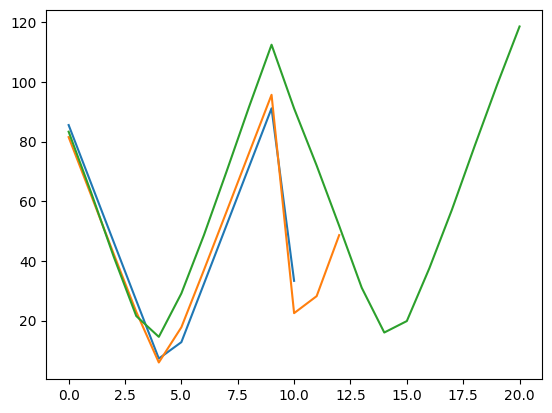

In [13]:
for W in W_l:
    plt.plot(np.linalg.norm(W, axis=0))

In [ ]:
from utils import *
C.length_corridors = [100]
C.max_move = 50

X, y, corridor, loc_X, loc_y, action_taken, dim_l, input_size, output_size, n_actions = create_data(C)

L = C.length_corridors[0]
A = C.max_move
n_model = 1
Win = np.concatenate([np.arange(1,L+1, 1), np.arange(-A,A+1)])[:,None]
Wout = 1/n_model*np.arange(1,L+1, 1)[None,:]**n_model
b = -1/(n_model+1)*np.arange(1,L+1, 1)[None, :]**(n_model+1)

W1,W2 = get_AB(X, Win, Wout, b, 2)
W = W1 @ W2
print(((X@W).argmax(1)==y.argmax(1)).mean())

1.0


6700417.0

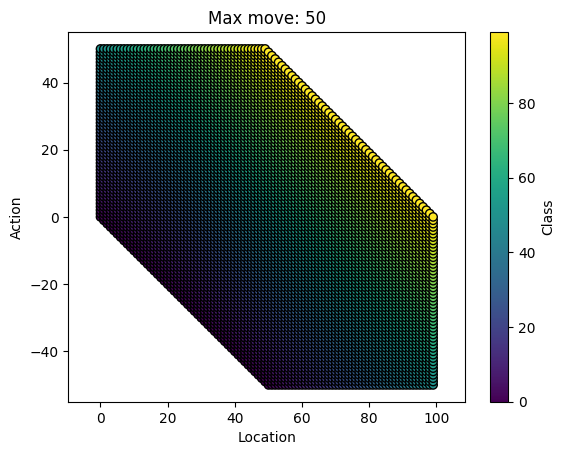

In [180]:

scatter = plt.scatter(loc_X, action_taken, c=loc_y, edgecolor='k')
plt.xlabel('Location')
plt.ylabel('Action')
plt.title(f'Max move: {C.max_move}')
plt.xlim(x_min-1, x_max+1)
plt.ylim(y_min-0.2, y_max+0.2)
plt.colorbar(scatter, label='Class')
plt.axis('equal')
plt.show()

ValueError: 'c' argument has 13 elements, which is inconsistent with 'x' and 'y' with size 169.

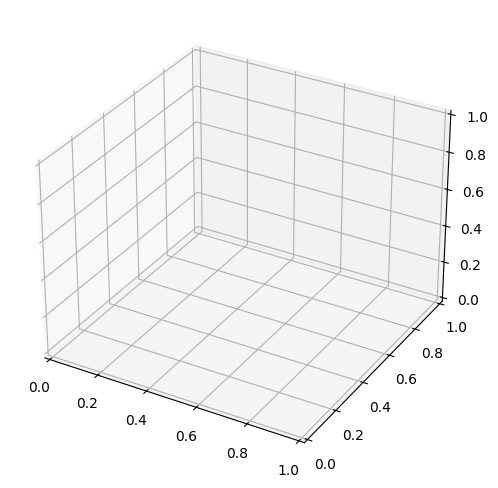

In [56]:
probabilities = X@W.T
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# If probabilities is (n_samples, n_classes), plot the max probability for each sample
if probabilities.ndim == 2:
    prob_vals = np.max(probabilities, axis=1)
else:
    prob_vals = probabilities

ax.scatter(loc_X, action_taken, prob_vals, c=prob_vals, marker='o')
ax.set_xlabel('Location')
ax.set_ylabel('Action Taken')
ax.set_zlabel('Probability')
ax.set_title('3D Scatter: Location, Action, Probability')
plt.show()


In [49]:
x= grid_points[-500]
print(x)
location = x[0]
action = x[1] - np.min(action_taken)
print(location, action)
print(int(np.round(location)), location - np.floor(location))
print(C.length_corridors[0]+int(np.round(action)), action - np.floor(action))

[9.69899666 0.97979798]
9.698996655518394 1.97979797979798
10 0.6989966555183944
32 0.9797979797979799


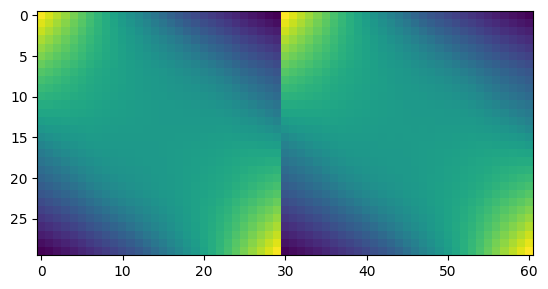

In [17]:
plt.imshow(W_l[1])